<a href="https://colab.research.google.com/github/youkjang/noaa-gefs-data/blob/main/notebooks/ensemble_spread_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NOAA Global Ensemble Forecast System (GEFS) from Amazon S3
###Plot Ensemble Mean and Spread

- Initial date: May 17, 2026
- Forecast hour: 120 hrs
- Forecast valid date: May 22, 2026 00 UTC



Packages for GEFS files
- ecodes: provide the GRIB-decoding engine
- cfgrib: xarray open GRIB files
- s3fs: access files stored in Amazon S3
- fsspec: A general filesystem interface used by packages like xarray, s3fs, and others to read files from local disks, cloud storage, URLs, etc.


##1. Install packages

In [2]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs fsspec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 62.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompa

In [13]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 52.5 MB/s eta 0:00:00


##2.Define one GEFS file path

In [3]:
import numpy as np
import xarray as xr
import s3fs
from pathlib import Path

fs = s3fs.S3FileSystem(anon=True)
cache_dir = Path("/content/gefs_cache")
cache_dir.mkdir(exist_ok=True)

init_date = "20260517"
cycle = "00"
fhr = 120

members = ["c00"] + [f"p{i:02d}" for i in range(1, 11)]  # 11-member starter

In [4]:
members

['c00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10']

##3. Download the GRIB2 file locally & Open 2m temperature

In [34]:
def open_t2m_member(init_date, cycle, member, fhr):
    fname = f"ge{member}.t{cycle}z.pgrb2a.0p50.f{fhr:03d}"
    s3_key = f"noaa-gefs-pds/gefs.{init_date}/{cycle}/atmos/pgrb2ap5/{fname}"
    local_file = cache_dir / fname

    if not local_file.exists():
        fs.get(s3_key, str(local_file))

    ds = xr.open_dataset(
        local_file,
        engine="cfgrib",
        backend_kwargs={
            "filter_by_keys": {
                "typeOfLevel": "heightAboveGround",
                "level": 2
            },
            "indexpath": ""
        }
    )

    da = ds["t2m"]

    da = da.assign_coords(
        longitude=((da.longitude + 180) % 360) - 180
    ).sortby("longitude")

#Select the U.S. region
    da = da.sel(
        longitude=slice(-125, -66),
        latitude=slice(50, 24)
    )

    return da.squeeze().expand_dims(member=[member])

- c00: Control forecast
- c01 ~ c10: Perturbed ensemble members 1 through 10

In [38]:
ens_list = []

for m in members:
    print("Opening", m)
    ens_list.append(open_t2m_member(init_date, cycle, m, fhr))

ens = xr.concat(ens_list, dim="member")

# Kelvin (K) to Celsius (°C)
ens_mean = ens.mean("member")-273.15
ens_spread = ens.std("member")

Opening c00
Opening p01
Opening p02
Opening p03
Opening p04
Opening p05
Opening p06
Opening p07
Opening p08
Opening p09
Opening p10


/tmp/ipykernel_14074/3256563923.py:7: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ens = xr.concat(ens_list, dim="member")


In [30]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

##Ensemble Mean

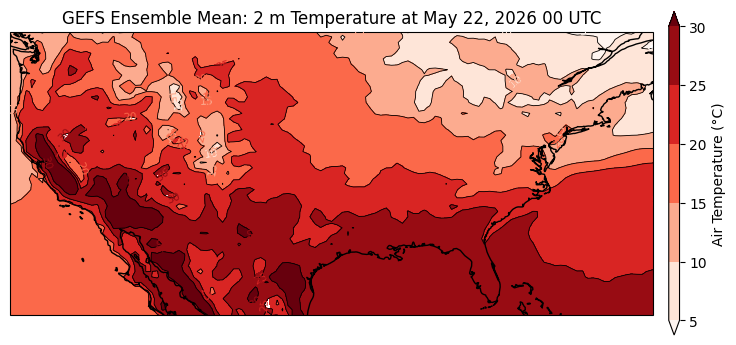

In [59]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))

contour_levels_temp = np.arange(5, 35, 5)
cs_temp = ax.contourf(ens_mean.longitude, ens_mean.latitude, ens_mean,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Reds', extend='both')
cs_temp_contour = ax.contour(ens_mean.longitude, ens_mean.latitude, ens_mean,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          colors='black',linewidths=0.6)

ax.coastlines()
plt.clabel(cs_temp, inline=True, fontsize=8, fmt='%1.0f')

# Add title and colorbar, then show the plot
plt.title('GEFS Ensemble Mean: 2 m Temperature at May 22, 2026 00 UTC')

plt.colorbar(cs_temp, label='Air Temperature (°C)',
              pad=0.02, aspect=30,shrink=0.7)
plt.show()


###Plot Ensemble Spread

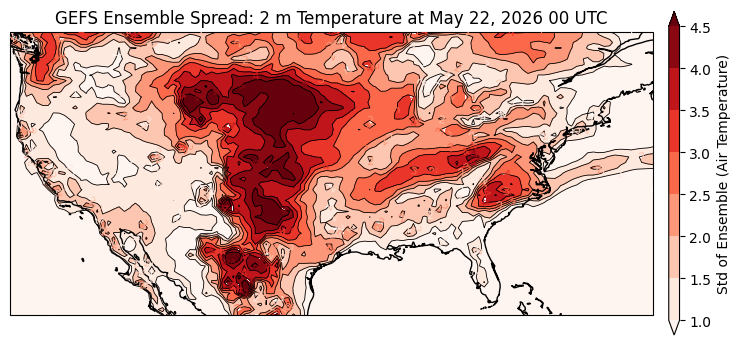

In [60]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))

contour_levels_temp = np.arange(1, 5, 0.5)
cs_temp = ax.contourf(ens_spread.longitude, ens_spread.latitude, ens_spread,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Reds', extend='both')
cs_temp_contour = ax.contour(ens_spread.longitude, ens_spread.latitude, ens_spread,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          colors='black',linewidths=0.6)

ax.coastlines()
plt.clabel(cs_temp, inline=True, fontsize=8, fmt='%1.0f')

# Add title and colorbar, then show the plot
plt.title('GEFS Ensemble Spread: 2 m Temperature at May 22, 2026 00 UTC')

plt.colorbar(cs_temp, label='Std of Ensemble (Air Temperature)',
             pad=0.02, aspect=30,shrink=0.7)
plt.show()

## Note on AI Assistance

ChatGPT was used as a coding assistant for drafting and debugging portions of the Python workflow.
All scientific decisions, code review, testing, and interpretation were performed by me.